<a href="https://colab.research.google.com/github/IDE21/Alzheimer-classification-Numeric-dataset/blob/main/Alzheimer_classification_cols.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 22.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import precision_recall_curve, roc_auc_score
import seaborn as sns

In [4]:
# Load dataset
df = pd.read_csv("/content/alzheimer-10 cols ver2 - classification.csv")

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Fill missing values (using KNN imputation for better accuracy)
from sklearn.impute import KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)
df[df.select_dtypes(include=np.number).columns] = knn_imputer.fit_transform(df.select_dtypes(include=np.number))

# Fill missing categorical values using mode
for column in df.select_dtypes(include=['object']).columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Check missing values after imputation
print("\nMissing values after imputation:")
print(df.isnull().sum())

# Encode categorical variables using LabelEncoder
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Encode target column 'Group'
le_group = LabelEncoder()
y = le_group.fit_transform(df['Group'])

# Scale numerical features
scaler = StandardScaler()
numerical_features = ['Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Feature matrix and target vector
X = df.drop("Group", axis=1)
y = df["Group"]

# Split the data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Missing values per column:
M/F       0
Age       0
EDUC      0
SES      19
MMSE      2
CDR       0
eTIV      0
nWBV      0
ASF       0
Group     0
dtype: int64

Missing values after imputation:
M/F      0
Age      0
EDUC     0
SES      0
MMSE     0
CDR      0
eTIV     0
nWBV     0
ASF      0
Group    0
dtype: int64


In [5]:
# Define hyperparameters for XGBoost
xgb_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.05, 0.1, 0.15]
}

# GridSearchCV for XGBoost
grid_search_xgb = GridSearchCV(XGBClassifier(objective='multi:softmax', num_class=len(y.unique()), random_state=42),
                               param_grid=xgb_params, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

# Best parameters and model
print("Best parameters for XGBoost:", grid_search_xgb.best_params_)
model_xgb = grid_search_xgb.best_estimator_

# Evaluate XGBoost on the test set
y_pred_xgb = model_xgb.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

Best parameters for XGBoost: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150}
XGBoost Accuracy: 0.88
Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.25      0.31         8
           1       0.96      0.90      0.93        29
           2       0.88      1.00      0.94        38

    accuracy                           0.88        75
   macro avg       0.75      0.72      0.72        75
weighted avg       0.86      0.88      0.87        75



In [6]:
# Train and Save XGBoost Model
joblib.dump(model_xgb, 'xgboost_model_tuned.pkl')

# Train LightGBM with tuned hyperparameters
lgb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 6, 7]
}
grid_search_lgb = GridSearchCV(LGBMClassifier(random_state=42), param_grid=lgb_params, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_lgb.fit(X_train, y_train)
model_lgb = grid_search_lgb.best_estimator_
joblib.dump(model_lgb, 'lightgbm_model_tuned.pkl')

# Train and Save CatBoost Model
cat_params = {
    'iterations': [100, 150],
    'learning_rate': [0.05, 0.1],
    'depth': [5, 6]
}
grid_search_cat = GridSearchCV(CatBoostClassifier(random_state=42, verbose=0), param_grid=cat_params, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_cat.fit(X_train, y_train)
model_cat = grid_search_cat.best_estimator_
model_cat.save_model('catboost_model_tuned.cbm')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 344
[LightGBM] [Info] Number of data points in the train set: 298, number of used features: 9
[LightGBM] [Info] Start training from score -2.329798
[LightGBM] [Info] Start training from score -0.934920
[LightGBM] [Info] Start training from score -0.673213
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

XGBoost Evaluation:
Accuracy: 0.88
Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.25      0.31         8
           1       0.96      0.90      0.93        29
           2       0.88      1.00      0.94        38

    accuracy                           0.88        75
   macro avg       0.75      0.72      0.72        75
weighted avg       0.86      0.88      0.87        75

Confusion Matrix:
 [[ 2  1  5]
 [ 3 26  0]
 [ 0  0 38]]

LightGBM Evaluation:
Accuracy: 0.91
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.12      0.22         8
           1       0.94      1.00      0.97        29
           2       0.88      1.00      0.94        38

    accuracy                           0.91        75
   macro avg       0.94      0.71      0.71        75
weighted avg       0.92      0.91      0.87        75

Confusion Matrix:
 [[ 1  2  5]
 [ 0 29  0]
 [ 0  0 38]]

CatBo

<ipython-input-8-76936ef9a3d6>:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


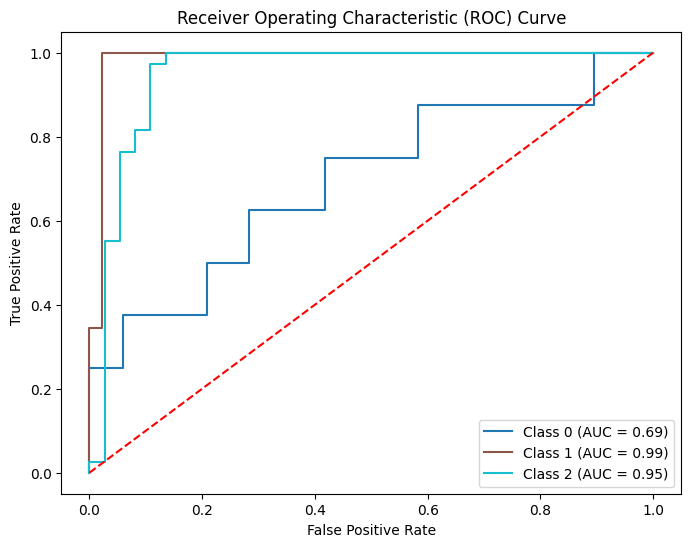


LightGBM ROC Curve:


<ipython-input-8-76936ef9a3d6>:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


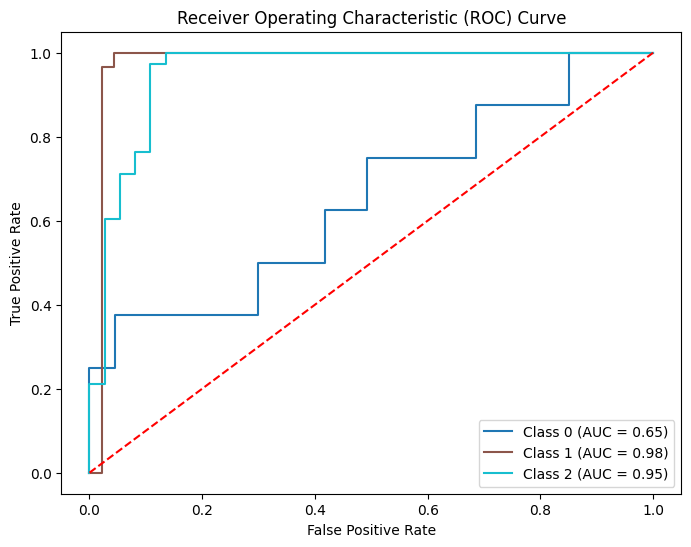


CatBoost ROC Curve:


<ipython-input-8-76936ef9a3d6>:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


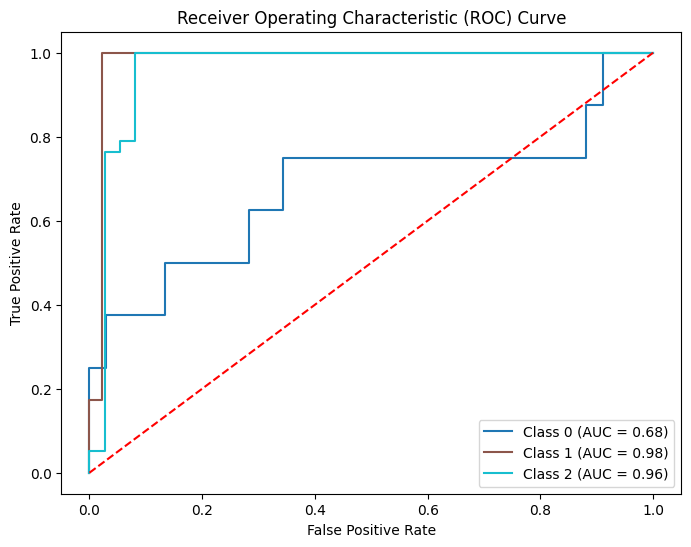

In [8]:
from sklearn.metrics import auc
# Evaluate all models and display metrics
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Evaluate XGBoost
print("XGBoost Evaluation:")
evaluate_model(model_xgb, X_test, y_test)

# Evaluate LightGBM
print("\nLightGBM Evaluation:")
evaluate_model(model_lgb, X_test, y_test)

# Evaluate CatBoost
print("\nCatBoost Evaluation:")
evaluate_model(model_cat, X_test, y_test)

# ROC-AUC Plot for Multi-Class Classification
def plot_roc_curve(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)
    n_classes = y_prob.shape[1]
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test == i, y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    colors = plt.cm.get_cmap('tab10', n_classes)

    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], color=colors(i), label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='r')  # Random classifier line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()

# Plot ROC Curve for XGBoost
print("XGBoost ROC Curve:")
plot_roc_curve(model_xgb, X_test, y_test)

# Plot ROC Curve for LightGBM
print("\nLightGBM ROC Curve:")
plot_roc_curve(model_lgb, X_test, y_test)

# Plot ROC Curve for CatBoost
print("\nCatBoost ROC Curve:")
plot_roc_curve(model_cat, X_test, y_test)

In [9]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [10]:
# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)

# Voting Classifier (Using XGBoost, RandomForest, and LightGBM models)
voting_model = VotingClassifier(estimators=[
    ('xgb', model_xgb),
    ('lgb', model_lgb),
    ('rf', rf_model)
], voting='soft')

# Stacking Classifier (using Logistic Regression as meta-classifier)
stacking_model = StackingClassifier(
    estimators=[
        ('xgb', model_xgb),
        ('lgb', model_lgb),
        ('rf', rf_model)
    ],
    final_estimator=LogisticRegression()
)

In [11]:
# Train and evaluate Random Forest
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.2f}")
print("Classification Report:\n", classification_report(y_test, rf_pred))

# Train and evaluate Voting Classifier
voting_model.fit(X_train, y_train)
voting_pred = voting_model.predict(X_test)
print("\nVoting Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, voting_pred):.2f}")
print("Classification Report:\n", classification_report(y_test, voting_pred))

# Train and evaluate Stacking Classifier
stacking_model.fit(X_train, y_train)
stacking_pred = stacking_model.predict(X_test)
print("\nStacking Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, stacking_pred):.2f}")
print("Classification Report:\n", classification_report(y_test, stacking_pred))

Random Forest Evaluation:
Accuracy: 0.92
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.25      0.40         8
           1       0.97      1.00      0.98        29
           2       0.88      1.00      0.94        38

    accuracy                           0.92        75
   macro avg       0.95      0.75      0.77        75
weighted avg       0.93      0.92      0.90        75

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000061 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 344
[LightGBM] [Info] Number of data points in the train set: 298, number of used features: 9
[LightGBM] [Info] Start training from score -2.329798
[LightGBM] [Info] Start training from score -0.934920
[LightGBM] [Info] Start training from score -0.673213
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 


XGBoost Accuracy: 0.88
Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.25      0.31         8
           1       0.96      0.90      0.93        29
           2       0.88      1.00      0.94        38

    accuracy                           0.88        75
   macro avg       0.75      0.72      0.72        75
weighted avg       0.86      0.88      0.87        75

Confusion Matrix:
 [[ 2  1  5]
 [ 3 26  0]
 [ 0  0 38]]


<ipython-input-12-1fe6282b7df6>:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


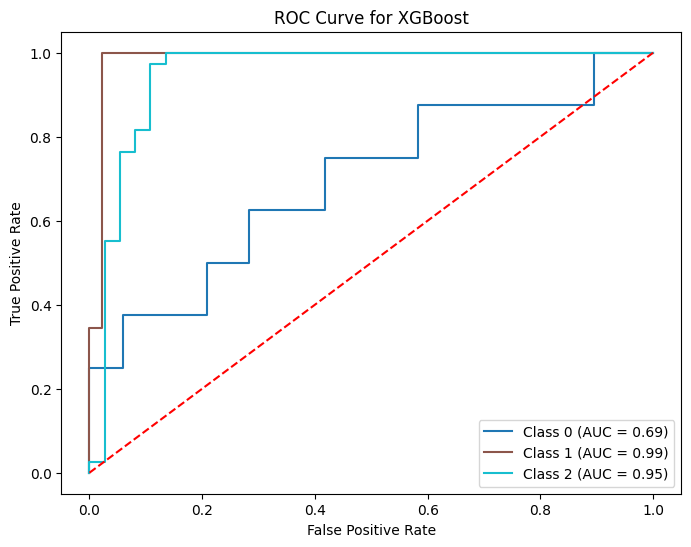


LightGBM Accuracy: 0.91
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.12      0.22         8
           1       0.94      1.00      0.97        29
           2       0.88      1.00      0.94        38

    accuracy                           0.91        75
   macro avg       0.94      0.71      0.71        75
weighted avg       0.92      0.91      0.87        75

Confusion Matrix:
 [[ 1  2  5]
 [ 0 29  0]
 [ 0  0 38]]


<ipython-input-12-1fe6282b7df6>:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


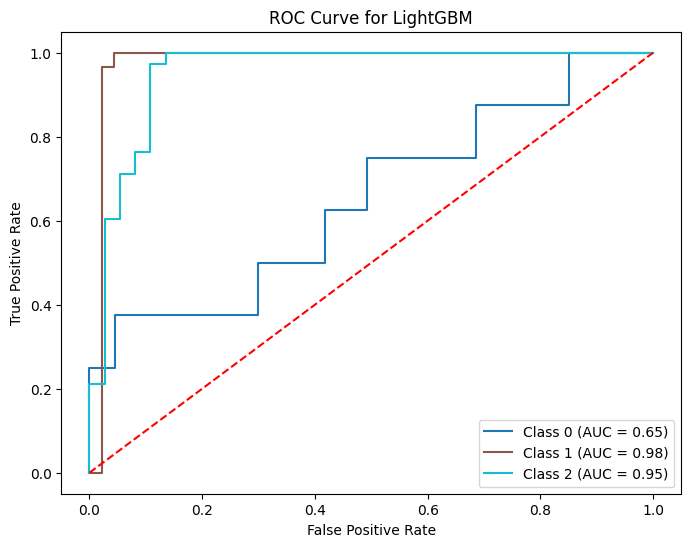


CatBoost Accuracy: 0.92
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.25      0.40         8
           1       0.97      1.00      0.98        29
           2       0.88      1.00      0.94        38

    accuracy                           0.92        75
   macro avg       0.95      0.75      0.77        75
weighted avg       0.93      0.92      0.90        75

Confusion Matrix:
 [[ 2  1  5]
 [ 0 29  0]
 [ 0  0 38]]


<ipython-input-12-1fe6282b7df6>:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


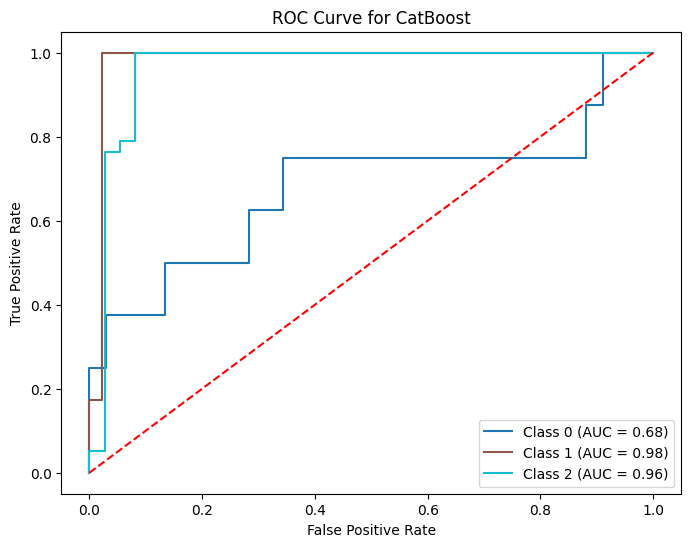


Random Forest Accuracy: 0.92
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.25      0.40         8
           1       0.97      1.00      0.98        29
           2       0.88      1.00      0.94        38

    accuracy                           0.92        75
   macro avg       0.95      0.75      0.77        75
weighted avg       0.93      0.92      0.90        75

Confusion Matrix:
 [[ 2  1  5]
 [ 0 29  0]
 [ 0  0 38]]


<ipython-input-12-1fe6282b7df6>:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


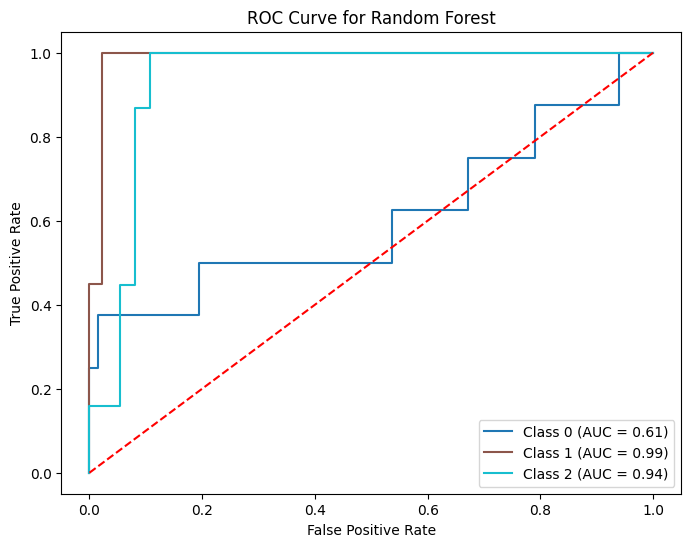


Voting Classifier Accuracy: 0.92
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.25      0.40         8
           1       0.97      1.00      0.98        29
           2       0.88      1.00      0.94        38

    accuracy                           0.92        75
   macro avg       0.95      0.75      0.77        75
weighted avg       0.93      0.92      0.90        75

Confusion Matrix:
 [[ 2  1  5]
 [ 0 29  0]
 [ 0  0 38]]


<ipython-input-12-1fe6282b7df6>:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


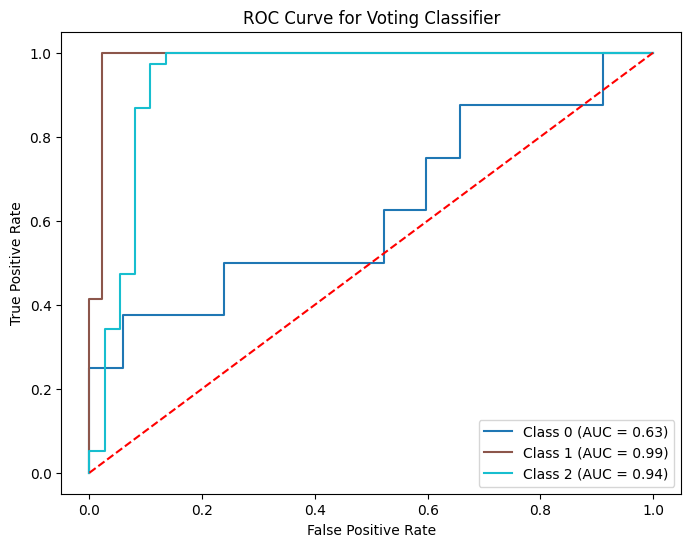


Stacking Classifier Accuracy: 0.91
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.12      0.22         8
           1       0.94      1.00      0.97        29
           2       0.88      1.00      0.94        38

    accuracy                           0.91        75
   macro avg       0.94      0.71      0.71        75
weighted avg       0.92      0.91      0.87        75

Confusion Matrix:
 [[ 1  2  5]
 [ 0 29  0]
 [ 0  0 38]]


<ipython-input-12-1fe6282b7df6>:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


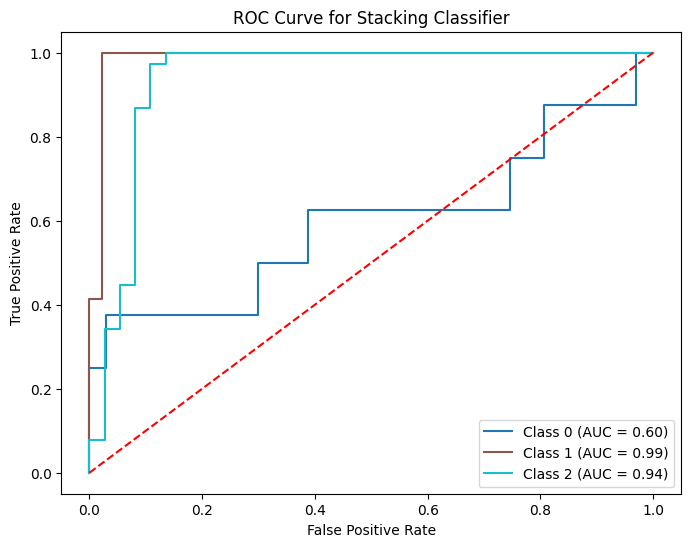

In [12]:
# Compare All Models: XGBoost, LightGBM, CatBoost, RF, Voting, Stacking

models = {
    'XGBoost': model_xgb,
    'LightGBM': model_lgb,
    'CatBoost': model_cat,
    'Random Forest': rf_model,
    'Voting Classifier': voting_model,
    'Stacking Classifier': stacking_model
}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n{model_name} Accuracy: {accuracy:.2f}")
    print(f"Classification Report:\n {classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}")

    # Plot ROC curve for each model
    y_prob = model.predict_proba(X_test)
    n_classes = y_prob.shape[1]
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test == i, y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    colors = plt.cm.get_cmap('tab10', n_classes)

    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], color=colors(i), label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='r')  # Random classifier line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend(loc='lower right')
    plt.show()

In [14]:
!pip install shap
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f607f6507ea11d83e149b6bbc7a1dcd2f7bd61480cf5bcc25ce101ef66baf5d2
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


<Figure size 640x480 with 0 Axes>

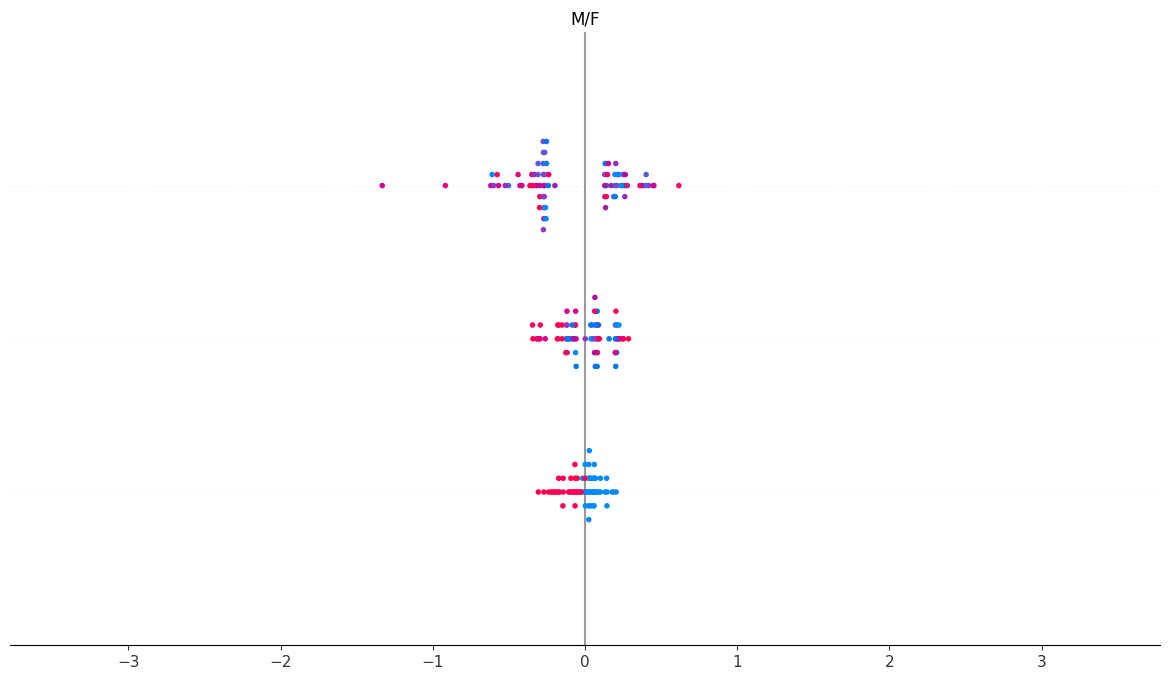

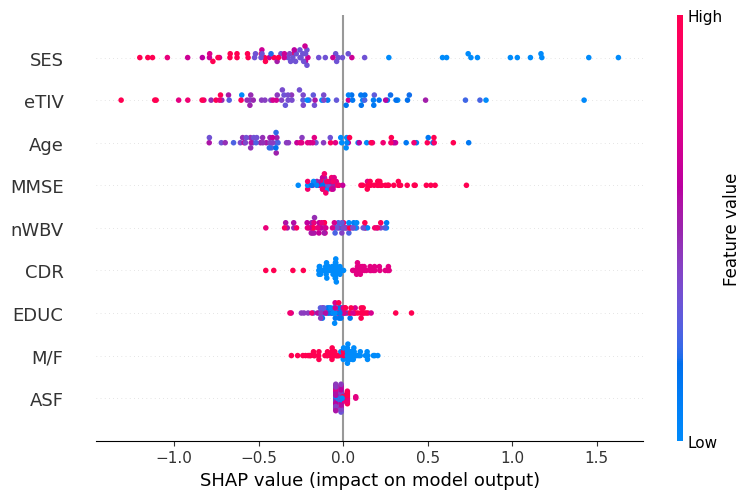

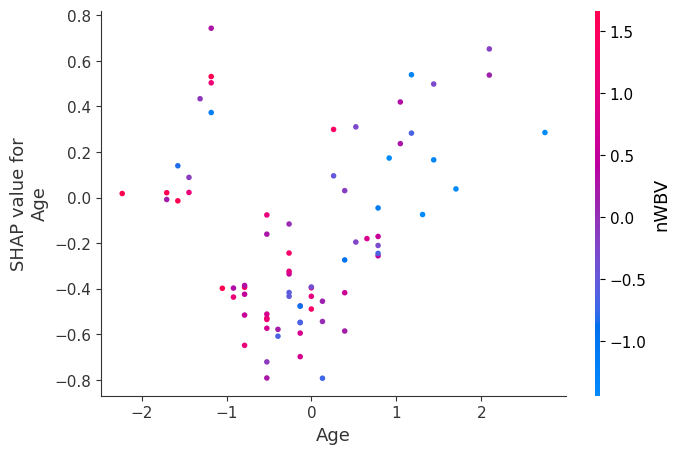

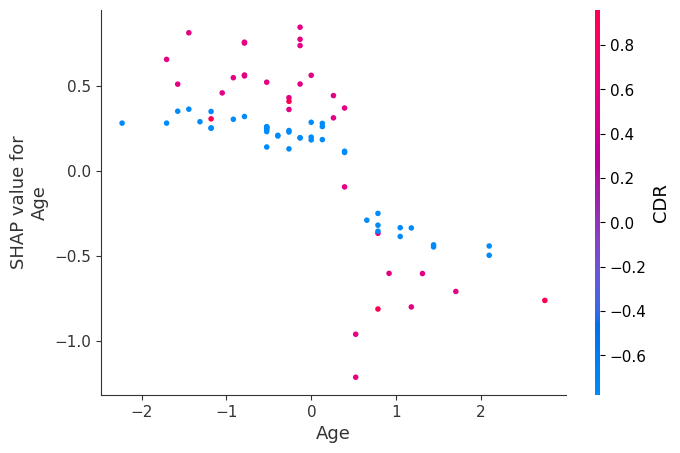

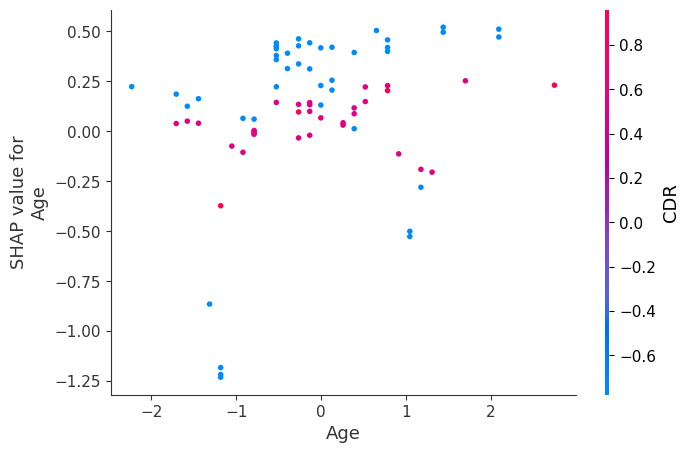

In [17]:
# SHAP for model explainability
import shap

# Use SHAP TreeExplainer for XGBoost, LightGBM, or CatBoost
explainer_xgb = shap.TreeExplainer(model_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# SHAP summary plot for global explanation
shap.summary_plot(shap_values_xgb, X_test)

# SHAP summary plot for a specific class (if multi-class classification)
shap.summary_plot(shap_values_xgb[:, :, 0], X_test)
# SHAP dependence plot for a specific feature
shap.dependence_plot('Age', shap_values_xgb[:, :, 0], X_test)  # Class 0
# or
shap.dependence_plot('Age', shap_values_xgb[:, :, 1], X_test)  # Class 1
# or
shap.dependence_plot('Age', shap_values_xgb[:, :, 2], X_test)  # Class 2
# LIME for local explanation of individual predictions
from lime.lime_tabular import LimeTabularExplainer

# Create a LimeTabularExplainer object for your model
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,        # Training features
    mode="classification",               # Classification problem
    training_labels=y_train.values,      # Training labels
    feature_names=X_train.columns,       # Feature names
    class_names=[str(i) for i in np.unique(y)],  # Class labels
    discretize_continuous=True           # Discretize continuous variables for better interpretability
)

# Choose an instance to explain (e.g., the first instance in the test set)
instance_idx = 0
instance = X_test.iloc[instance_idx].values.reshape(1, -1)

lime_explanation = explainer_lime.explain_instance(instance[0], model_xgb.predict_proba)

# Visualize the LIME explanation
lime_explanation.show_in_notebook(show_table=True, show_all=False)

In [13]:
import joblib

# Save Random Forest Model
joblib.dump(rf_model, 'random_forest_model.joblib')

# Save Voting Classifier Model
joblib.dump(voting_model, 'voting_classifier_model.joblib')

# Save Stacking Classifier Model
joblib.dump(stacking_model, 'stacking_classifier_model.joblib')

# Save XGBoost Model
joblib.dump(model_xgb, 'xgboost_model.joblib')

# Save LightGBM Model
joblib.dump(model_lgb, 'lightgbm_model.joblib')

# Save CatBoost Model
joblib.dump(model_cat, 'catboost_model.joblib')

print("Models saved successfully.")

Models saved successfully.
